# DATA COLLECTION AND UNDERSTANDING

In [1]:
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv(r"C:\Users\kelly\Downloads\global_test_set.csv")

In [3]:
dataset.head()

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
0,1195586,1062,A.M-E.C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
1,1195586,1063,R.A-C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
2,1195586,8.90425E+12,istovin 20mg,Capsule,3,2,0,4/7/2024,2:51PM,Drug
3,1195586,4.26022E+12,caelin %2 sulfur,Soap,1,1,1,4/7/2024,2:51PM,Supply
4,1195586,4.26012E+12,TMS forte 800/160mg,Tablet,1,2,2,4/7/2024,2:51PM,Drug


In [4]:
dataset.shape

(240591, 10)

In [5]:
dataset.isnull().sum()

Invoice            0
barcode            0
name               0
dosage_form    18303
Sheet              0
Sales_Sheet        0
Sales_pack         0
addeddate          0
time_              0
type               0
dtype: int64

In [6]:
dataset.duplicated().sum()

np.int64(1637)

In [7]:
dataset.drop_duplicates(inplace = True)

In [8]:
dataset.duplicated().sum()

np.int64(0)

In [9]:
dataset.info()

<class 'pandas.DataFrame'>
Index: 238954 entries, 0 to 240590
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Invoice      238954 non-null  int64
 1   barcode      238954 non-null  str  
 2   name         238954 non-null  str  
 3   dosage_form  220739 non-null  str  
 4   Sheet        238954 non-null  int64
 5   Sales_Sheet  238954 non-null  int64
 6   Sales_pack   238954 non-null  int64
 7   addeddate    238954 non-null  str  
 8   time_        238954 non-null  str  
 9   type         238954 non-null  str  
dtypes: int64(4), str(6)
memory usage: 32.7 MB


# DATA CLEANING AND PREPARATION


In [10]:
import re

def check_format_inconsistencies(dataset):
    issues = {}

    text_cols = dataset.select_dtypes(include="object").columns

    for col in text_cols:
        col_issues = {}

        
        col_issues["leading_trailing_spaces"] = dataset[col].astype(str).str.match(r"^\s|\s$").sum()

       
        col_issues["mixed_case_count"] = dataset[col].dropna().astype(str).apply(
            lambda x: not (x.islower() or x.isupper() or x.istitle())
        ).sum()

       
        col_issues["extra_internal_spaces"] = dataset[col].astype(str).str.contains(r"\s{2,}", regex=True).sum()

      
        col_issues["special_characters"] = dataset[col].astype(str).str.contains(r"[^a-zA-Z0-9\s]", regex=True).sum()

        issues[col] = col_issues

    return issues



In [11]:
result = check_format_inconsistencies(dataset)
print(result)

{'barcode': {'leading_trailing_spaces': np.int64(0), 'mixed_case_count': np.int64(33055), 'extra_internal_spaces': np.int64(0), 'special_characters': np.int64(198991)}, 'name': {'leading_trailing_spaces': np.int64(12083), 'mixed_case_count': np.int64(126471), 'extra_internal_spaces': np.int64(7597), 'special_characters': np.int64(100790)}, 'dosage_form': {'leading_trailing_spaces': np.int64(4915), 'mixed_case_count': np.int64(2124), 'extra_internal_spaces': np.int64(12), 'special_characters': np.int64(1152)}, 'addeddate': {'leading_trailing_spaces': np.int64(0), 'mixed_case_count': np.int64(238954), 'extra_internal_spaces': np.int64(0), 'special_characters': np.int64(238954)}, 'time_': {'leading_trailing_spaces': np.int64(0), 'mixed_case_count': np.int64(0), 'extra_internal_spaces': np.int64(0), 'special_characters': np.int64(238954)}, 'type': {'leading_trailing_spaces': np.int64(0), 'mixed_case_count': np.int64(0), 'extra_internal_spaces': np.int64(0), 'special_characters': np.int64(0

In [12]:
cleaned =  dataset.copy()

In [13]:
cleaned["addeddate"] = pd.to_datetime(cleaned["addeddate"], errors = "coerce")

In [14]:
cleaned["addeddate"].isnull().sum()

np.int64(0)

In [15]:
cleaned["barcode"] = (cleaned["barcode"]
                      .astype(str)
                      .str.strip()
                      .str.replace(r"[^a-zA-Z0-9]", "", regex = True))  

In [16]:
cleaned["name"] = (
    cleaned["name"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+","", regex = True))

In [17]:
cleaned["dosage_form"] = (
    cleaned["dosage_form"]
    .astype(str)
    .str.strip()
    .str.lower())

In [18]:
check_format_inconsistencies(cleaned)

{'barcode': {'leading_trailing_spaces': np.int64(0),
  'mixed_case_count': np.int64(33052),
  'extra_internal_spaces': np.int64(0),
  'special_characters': np.int64(0)},
 'name': {'leading_trailing_spaces': np.int64(0),
  'mixed_case_count': np.int64(128),
  'extra_internal_spaces': np.int64(0),
  'special_characters': np.int64(100790)},
 'dosage_form': {'leading_trailing_spaces': np.int64(0),
  'mixed_case_count': np.int64(1),
  'extra_internal_spaces': np.int64(12),
  'special_characters': np.int64(1152)},
 'time_': {'leading_trailing_spaces': np.int64(0),
  'mixed_case_count': np.int64(0),
  'extra_internal_spaces': np.int64(0),
  'special_characters': np.int64(238954)},
 'type': {'leading_trailing_spaces': np.int64(0),
  'mixed_case_count': np.int64(0),
  'extra_internal_spaces': np.int64(0),
  'special_characters': np.int64(0)}}

In [19]:
cleaned["barcode"].head(20)

0          1062
1          1063
2     890425E12
3     426022E12
4     426012E12
5     426022E12
6          1067
7     426022E12
8           215
9          1062
10    426012E12
11          215
12         1066
13    570219E12
14    625107E12
15    570219E12
16    625116E12
17    869957E12
18     62911E12
19     62911E12
Name: barcode, dtype: str

In [20]:
# Fixed the character range from 'O-9' to '0-9' in the regex pattern
cleaned["name"].str.extractall(r"([^a-zA-Z0-9\s])")[0].value_counts().head(20)

0
/    41155
-    35757
.    35094
%    16069
+     6650
&     3998
,     2105
*     1357
(     1318
)     1317
`      664
_      369
;      277
ا      122
ص      122
ل      122
'      116
:       92
ى       91
[       80
Name: count, dtype: int64

In [21]:
cleaned["name"].str.extractall(r"([^a-zA-Z0-9\s])")[0].value_counts().head(20)

0
/    41155
-    35757
.    35094
%    16069
+     6650
&     3998
,     2105
*     1357
(     1318
)     1317
`      664
_      369
;      277
ا      122
ص      122
ل      122
'      116
:       92
ى       91
[       80
Name: count, dtype: int64

In [22]:
cleaned["dosage_form"].str.extractall(r"([^a-zA-Z0-9\s])")[0].value_counts().head(20)

0
.    891
-    193
&     52
/     31
,     30
+     23
ه      2
ي      1
خ      1
ى      1
م      1
ل      1
~      1
Name: count, dtype: int64

In [23]:
dataset['name'].unique()

<ArrowStringArray>
[                                     'A.M-E.C',
                                        'R.A-C',
                                 'istovin 20mg',
                             'caelin %2 sulfur',
                          'TMS forte 800/160mg',
                        'CAELIN VITAMIN E PLUS',
                                    'S.A %3 -D',
                               'Allermine 25mg',
                                    'Novo AIWA',
                                        'S-Z.O',
 ...
                                'Norcutin 5mg ',
                      'La roche-posay mela b3 ',
 'FILORGA TIME-FILLER 5XP Gel-Creme correction',
                                    'Otimo 6M+',
                             'Neuro fact plus ',
                       'Hola Vitamin D3 5000IU',
                          'Men Gel Larger Size',
                             'Kapeet max delay',
                                   'Mir-colon ',
                                   'Sacuzac 5

In [24]:
dataset['dosage_form'].unique()

<ArrowStringArray>
[         'gerawa',         'Capsule',            'Soap',          'Tablet',
           'Cream',         'Shampoo',       'Oral drop',      'test strip',
          'Lotion',             'gel',
 ...
         'strips~',          'Balsam',     'halgri mnal',          'Gochan',
        'leave-in', 'Moist Treatment',          'holder',            'tube',
    'bath fizzers',         'storage']
Length: 548, dtype: str

In [25]:
dataset['Sheet'].unique()

array([  1,   3,   4,   2,   6,  24, 100,  33,   8,  10,  30,   5,   7,
        50,  20,  42,  60, 250, 150,  40,  14,  28,  25,  21,  16,  12,
        18,  15,   9,  32,  45, 500,  22])

In [26]:
dataset['Sales_Sheet'].unique()

array([  1,   2,   4,   6,   3,  10,   5,   7,  13,  12,   9,  16,   8,
        20,  30,  14,  60,  80,  40, 150,  15,   0,  17,  50,  48,  24,
        11,  90,  28,  93,  25,  27, 200,  36, 250, 100,  21, 160,  72,
        37,  18, 157, 126,  32, 180,  95, 249, 125,  45,  29,  34,  26,
        44,  96,  22,  62,  53,  31,  64,  67,  35, 130,  41, 350,  19,
        83,  89, 120,  38,  70,  33,  23,  39,  59, 106, 144,  78,  49,
        43,  61, 380,  82,  68])

In [27]:
dataset['Sales_pack'].unique()

array([  1,   0,   2,  10,   3,   5,   6,   4,   8,  13,  12,  14,   7,
        20,  40,  50,   9,  48,  16,  11,  30,  15,  25,  36,  80, 100,
        18, 157,  29,  17,  22,  31,  19,  24,  64,  28,  21,  26,  45,
        41, 350,  83, 120,  38,  70,  60,  39, 106,  62, 144,  96,  49,
        23,  27,  37,  53,  35,  43,  61,  32,  82, 150,  90,  68])

In [28]:
dataset['addeddate'].unique()

<ArrowStringArray>
[  '4/7/2024',  '8/31/2024',  '10/6/2024',  '5/16/2024',  '9/16/2024',
   '6/7/2024',   '4/3/2024',   '3/1/2024',  '1/31/2024',  '10/2/2024',
 ...
  '10/3/2024',   '8/6/2024',  '9/12/2024',  '9/14/2024', '10/29/2024',
 '11/15/2024',  '6/11/2024',  '11/5/2024', '12/24/2024', '12/23/2024']
Length: 366, dtype: str

In [29]:
dataset['type'].unique()

<ArrowStringArray>
['Drug', 'Supply']
Length: 2, dtype: str

In [30]:
dataset.describe()

,Invoice,Sheet,Sales_Sheet,Sales_pack
count,2.389540e+05,238954.000000,238954.000000,238954.000000
mean,7.546098e+05,2.548491,1.996644,1.134294
std,4.332679e+05,6.349054,4.063359,1.957578
min,2.300000e+01,1.000000,0.000000,0.000000
25%,3.718288e+05,1.000000,1.000000,1.000000
50%,7.602280e+05,1.000000,1.000000,1.000000
75%,1.173566e+06,2.000000,2.000000,1.000000
max,1.429333e+06,500.000000,380.000000,350.000000


In [31]:
import scipy 
from scipy import stats as st
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: ylabel='Sheet'>

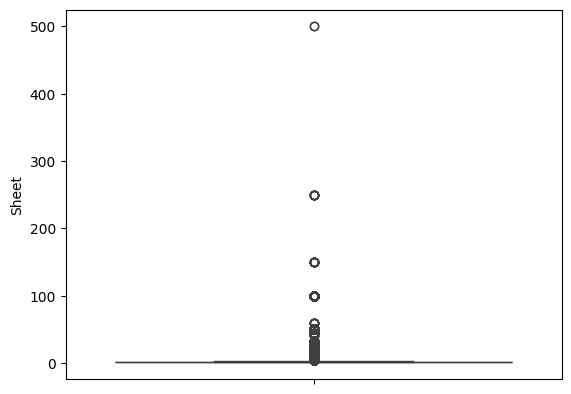

In [32]:
sns.boxplot( y = 'Sheet' , data = dataset)

In [33]:
Q3 = dataset.Sheet.quantile(0.75) 
print(Q3)

2.0


In [34]:
Q1 = dataset.Sheet.quantile(0.25) 
print(Q1)

1.0


In [35]:
IQR = Q3 - Q1 
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [36]:
dataset[(dataset['Sheet'] < lower_limit) | (dataset['Sheet'] > upper_limit)]

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
19,1195665,6.2911E+12,Julmentin fort 625mg,Tablet,4,4,1,3/1/2024,11:31AM,Drug
42,1195738,3.6604E+12,cystiphane biorga,Tablet,6,6,1,8/3/2024,4:33PM,Drug
106,1195955,-1319732,micropore 3m SPi plaster lut,instrument,24,5,0,3/3/2024,2:24PM,Supply
185,1196247,-1319732,micropore 3m SPi plaster lut,instrument,24,5,0,5/23/2024,3:07PM,Supply
196,1196271,-1319732,micropore 3m SPi plaster lut,instrument,24,5,0,9/18/2024,4:34PM,Supply
...,...,...,...,...,...,...,...,...,...,...
240578,1195466,8.90605E+12,Labmox 500mg,Capsule,10,4,0,11/1/2024,4:29PM,Drug
240579,1195466,173UTR,Speedo,sachet,30,10,0,11/1/2024,4:29PM,Drug
240580,1195476,6.0914E+12,imuran 50mg 100tablet / aspen,Tablet,4,1,0,10/4/2024,4:46PM,Drug
240584,1195485,173UTR,Speedo,sachet,30,2,0,7/14/2024,5:00PM,Drug


In [37]:
cleaned = dataset[(dataset['Sheet'] >= lower_limit) & (dataset['Sheet'] <= upper_limit)]

<Axes: ylabel='Sheet'>

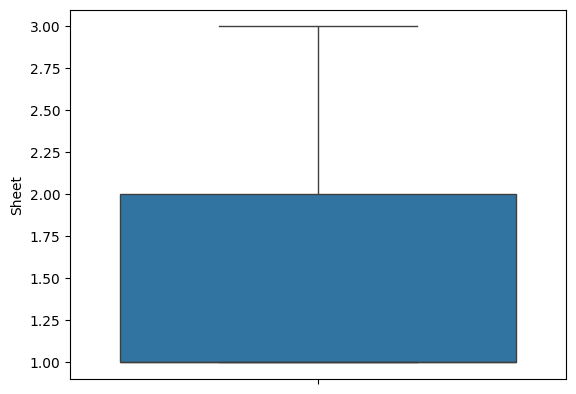

In [38]:
sns.boxplot( y = 'Sheet', data = cleaned)

<Axes: ylabel='Sales_Sheet'>

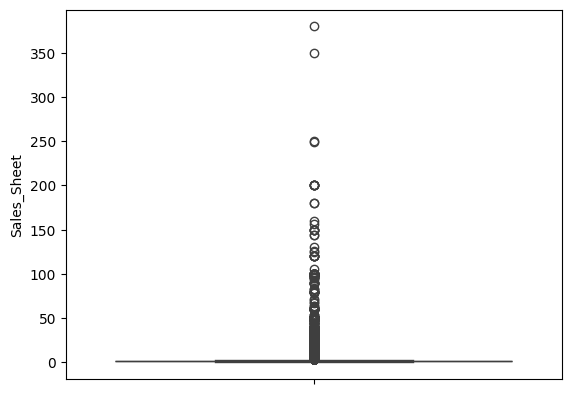

In [39]:
sns.boxplot( y = 'Sales_Sheet' , data = dataset)

In [40]:
Q3 = dataset.Sales_Sheet.quantile(0.75) 
print(Q3)

2.0


In [41]:
Q1 = dataset.Sales_Sheet.quantile(0.25) 
print(Q1)

1.0


In [42]:
IQR = Q3 - Q1 
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [43]:
dataset[(dataset['Sales_Sheet'] < lower_limit) | (dataset['Sales_Sheet'] > upper_limit)]

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
19,1195665,6.2911E+12,Julmentin fort 625mg,Tablet,4,4,1,3/1/2024,11:31AM,Drug
42,1195738,3.6604E+12,cystiphane biorga,Tablet,6,6,1,8/3/2024,4:33PM,Drug
72,1195824,4.26022E+12,CAELIN BABY CARE,Soap,1,10,10,8/13/2024,1:42PM,Supply
106,1195955,-1319732,micropore 3m SPi plaster lut,instrument,24,5,0,3/3/2024,2:24PM,Supply
185,1196247,-1319732,micropore 3m SPi plaster lut,instrument,24,5,0,5/23/2024,3:07PM,Supply
...,...,...,...,...,...,...,...,...,...,...
240512,1195033,2759,Girawa,soap,1,7,7,1/30/2024,2:45PM,Drug
240529,1195104,-7239879,Carbimazole Aristo 5mg /50tab.,Tablet,2,10,5,1/14/2024,4:28PM,Drug
240539,1195202,4.03157E+12,brain active,NaN,5,5,1,4/6/2024,10:50PM,Drug
240578,1195466,8.90605E+12,Labmox 500mg,Capsule,10,4,0,11/1/2024,4:29PM,Drug


In [44]:
cleaned = dataset[(dataset['Sales_Sheet'] >= lower_limit) & (dataset['Sales_Sheet'] <= upper_limit)]

<Axes: ylabel='Sales_Sheet'>

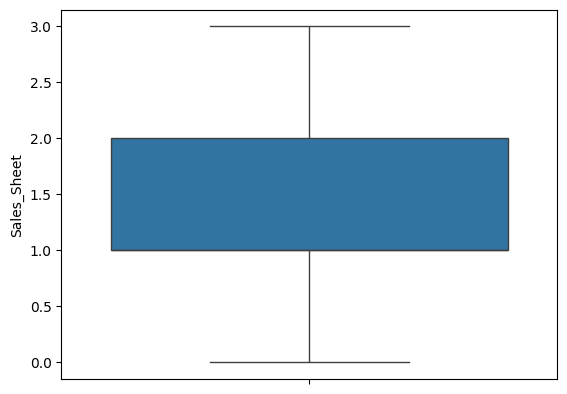

In [45]:
sns.boxplot( y = 'Sales_Sheet', data = cleaned)

<Axes: ylabel='Sales_pack'>

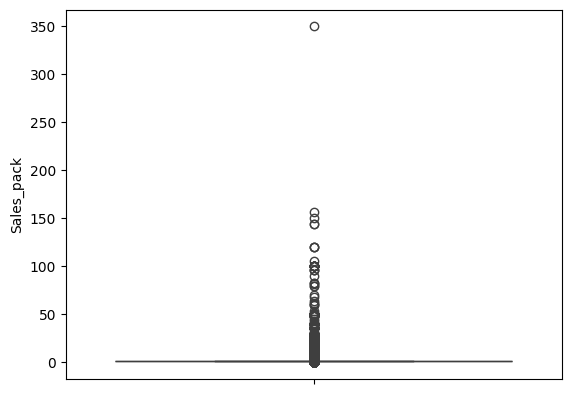

In [46]:
sns.boxplot( y = 'Sales_pack' , data = dataset)

In [47]:
Q3 = dataset.Sales_pack.quantile(0.75) 
print(Q3)

1.0


In [48]:
Q1 = dataset.Sales_pack.quantile(0.25) 
print(Q1)

1.0


In [49]:
IQR = Q3 - Q1 
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [50]:
dataset[(dataset['Sales_pack'] < lower_limit) | (dataset['Sales_pack'] > upper_limit)]

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
2,1195586,8.90425E+12,istovin 20mg,Capsule,3,2,0,4/7/2024,2:51PM,Drug
4,1195586,4.26012E+12,TMS forte 800/160mg,Tablet,1,2,2,4/7/2024,2:51PM,Drug
8,1195595,215,Allermine 25mg,Tablet,1,2,2,10/6/2024,3:45PM,Drug
20,1195665,6.25188E+12,Midagyl 500,Tablet,2,1,0,3/1/2024,11:31AM,Drug
49,1195750,6.2911E+12,Julmentin 2X 1000mg,Tablet,3,1,0,3/6/2024,5:00PM,Drug
...,...,...,...,...,...,...,...,...,...,...
240580,1195476,6.0914E+12,imuran 50mg 100tablet / aspen,Tablet,4,1,0,10/4/2024,4:46PM,Drug
240582,1195477,4.82001E+12,Ketosma 1mg Lekhim,Tablet,3,1,0,10/11/2024,4:46PM,Drug
240584,1195485,173UTR,Speedo,sachet,30,2,0,7/14/2024,5:00PM,Drug
240586,1195491,Auto-227,Lafaf 15cm,NaN,1,3,3,1/16/2024,5:12PM,Drug


In [51]:
cleaned = dataset[(dataset['Sales_pack'] >= lower_limit) & (dataset['Sales_pack'] <= upper_limit)]

<Axes: ylabel='Sales_pack'>

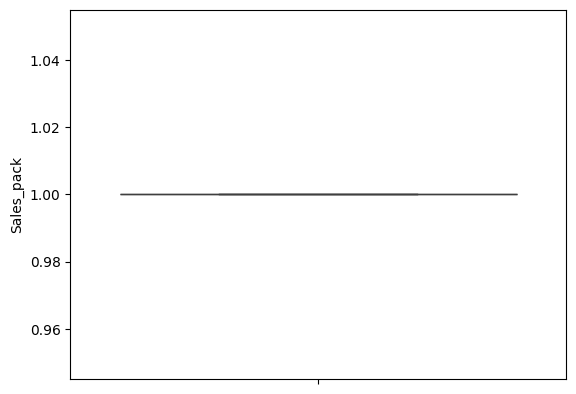

In [52]:
sns.boxplot( y = 'Sales_pack', data = cleaned)

In [53]:
print(type(cleaned))


<class 'pandas.DataFrame'>


In [54]:
print(type(cleaned))

<class 'pandas.DataFrame'>


In [55]:
dataset = cleaned

In [56]:
print(type(cleaned))
%who

<class 'pandas.DataFrame'>
IQR	 Q1	 Q3	 check_format_inconsistencies	 cleaned	 dataframe_columns	 dataframe_hash	 dataset	 dtypes_str	 
get_dataframes	 getpass	 hashlib	 import_pandas_safely	 is_data_frame	 json	 lower_limit	 pd	 plt	 
re	 result	 scipy	 sns	 st	 upper_limit	 warnings	 


In [57]:
dataset.head()

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
0,1195586,1062,A.M-E.C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
1,1195586,1063,R.A-C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
3,1195586,4.26022E+12,caelin %2 sulfur,Soap,1,1,1,4/7/2024,2:51PM,Supply
5,1195590,4.26022E+12,CAELIN VITAMIN E PLUS,Soap,1,1,1,8/31/2024,3:25PM,Supply
6,1195595,1067,S.A %3 -D,gerawa,1,1,1,10/6/2024,3:45PM,Drug


# EXPLORATORY DATA ANALYSIS

In [58]:
cleaned.describe()

,Invoice,Sheet,Sales_Sheet,Sales_pack
count,1.798040e+05,179804.000000,179804.000000,179804.0
mean,7.595913e+05,1.627517,1.639691,1.0
std,4.332004e+05,3.001012,3.049928,0.0
min,2.300000e+01,1.000000,1.000000,1.0
25%,3.767225e+05,1.000000,1.000000,1.0
50%,7.701385e+05,1.000000,1.000000,1.0
75%,1.177696e+06,1.000000,1.000000,1.0
max,1.429333e+06,150.000000,249.000000,1.0


In [59]:
import matplotlib 
from matplotlib import pyplot as plt

In [60]:
numeric_data =  cleaned.select_dtypes(include=['int64', 'float64'])

In [61]:
corr_matrix = numeric_data.corr()

In [62]:
numeric_data.corr()

,Invoice,Sheet,Sales_Sheet,Sales_pack
Invoice,1.000000,-0.027706,-0.026001,NaN
Sheet,-0.027706,1.000000,0.995925,NaN
Sales_Sheet,-0.026001,0.995925,1.000000,NaN
Sales_pack,NaN,NaN,NaN,NaN


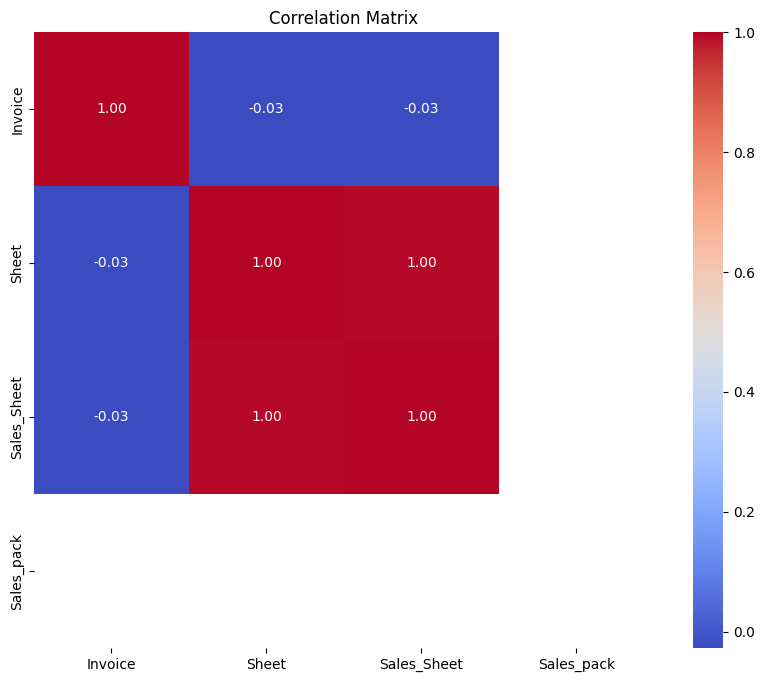

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

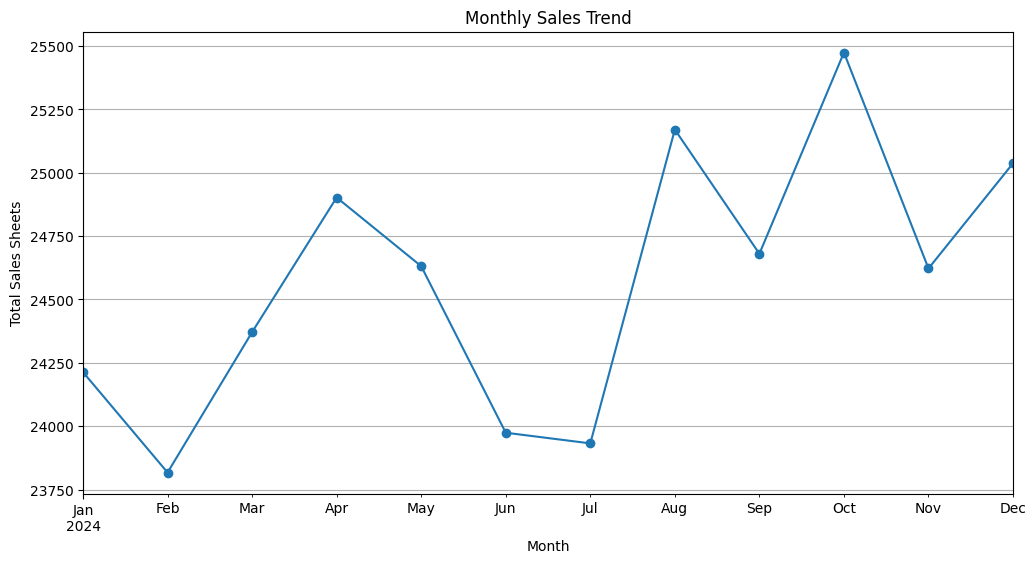

In [64]:
cleaned['addeddate'] = pd.to_datetime(cleaned['addeddate'])

monthly_sales = cleaned.groupby(
    cleaned['addeddate'].dt.to_period('M')  
)['Sales_Sheet'].sum()

monthly_sales.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Sheets')
plt.grid(True)

plt.show()

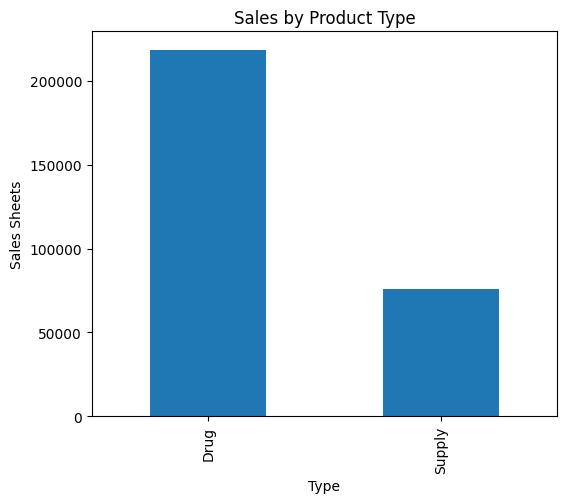

In [65]:
type_sales = cleaned.groupby('type')['Sales_Sheet'].sum()

type_sales.plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Sales by Product Type')
plt.xlabel('Type')
plt.ylabel('Sales Sheets')

plt.show()

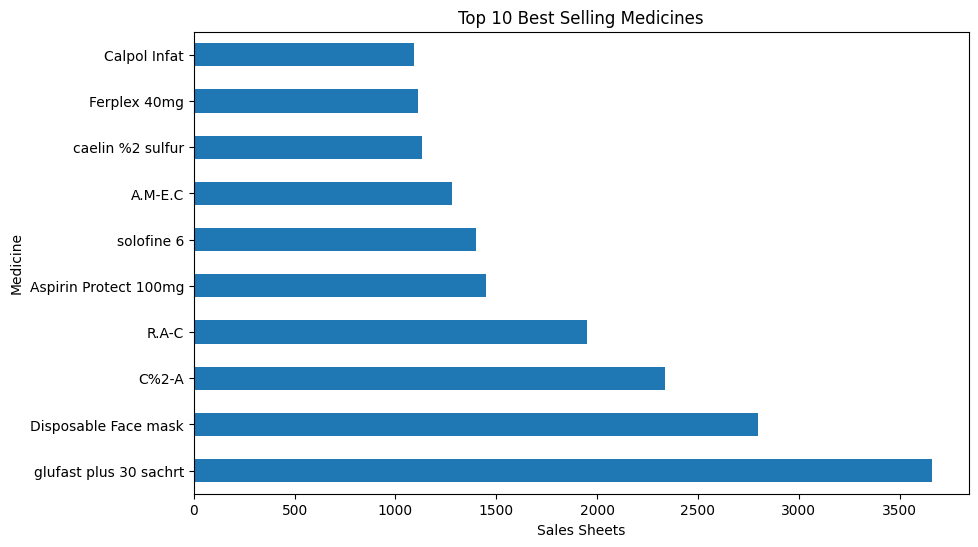

In [66]:
top10 = cleaned.groupby('name')['Sales_Sheet'].sum() \
          .sort_values(ascending=False) \
          .head(10)

top10.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Best Selling Medicines')
plt.xlabel('Sales Sheets')
plt.ylabel('Medicine')

plt.show()

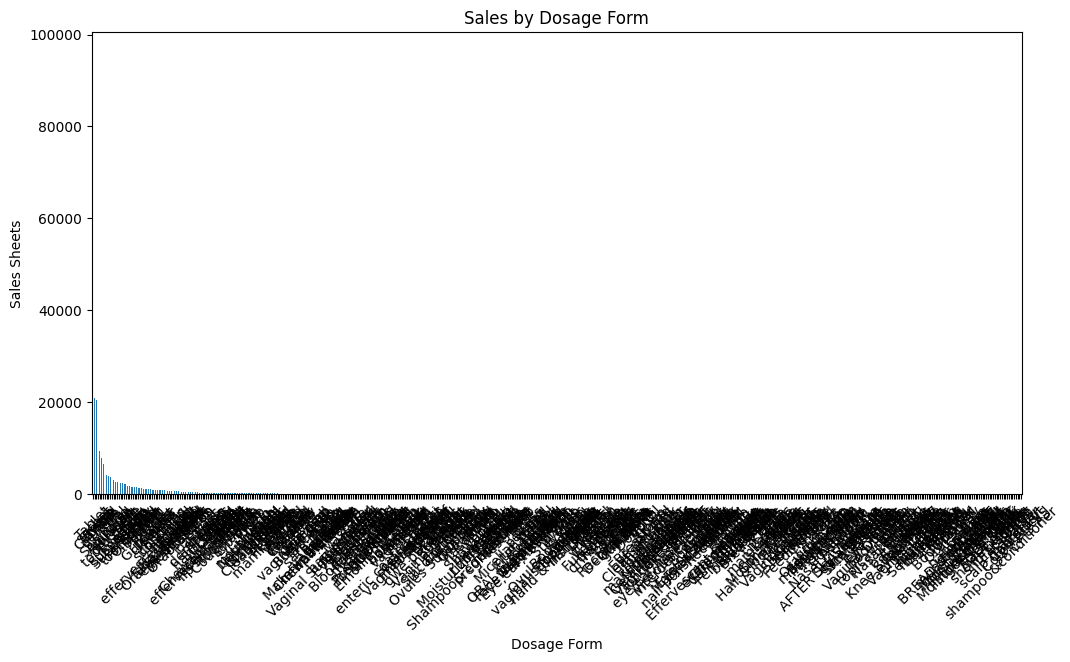

In [67]:
dosage_sales = cleaned.groupby('dosage_form')['Sales_Sheet'].sum() \
                 .sort_values(ascending=False)

dosage_sales.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Sales by Dosage Form')
plt.xlabel('Dosage Form')
plt.ylabel('Sales Sheets')

plt.xticks(rotation=45)

plt.show()

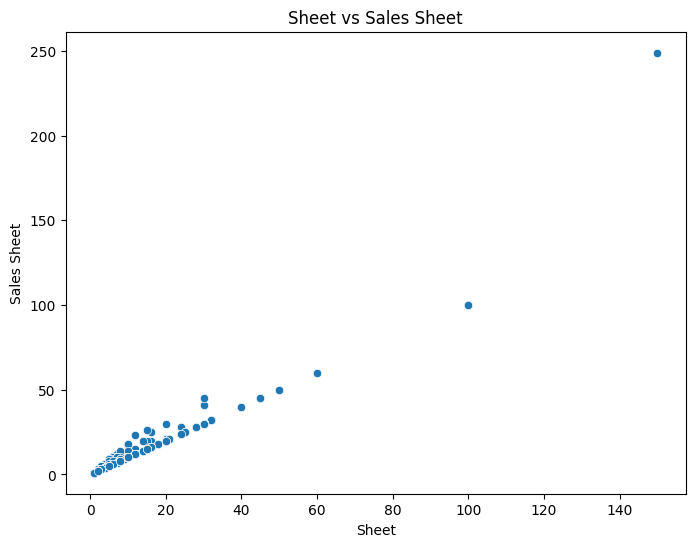

In [68]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cleaned,
    x='Sheet',
    y='Sales_Sheet'
)

plt.title('Sheet vs Sales Sheet')
plt.xlabel('Sheet')
plt.ylabel('Sales Sheet')

plt.show()

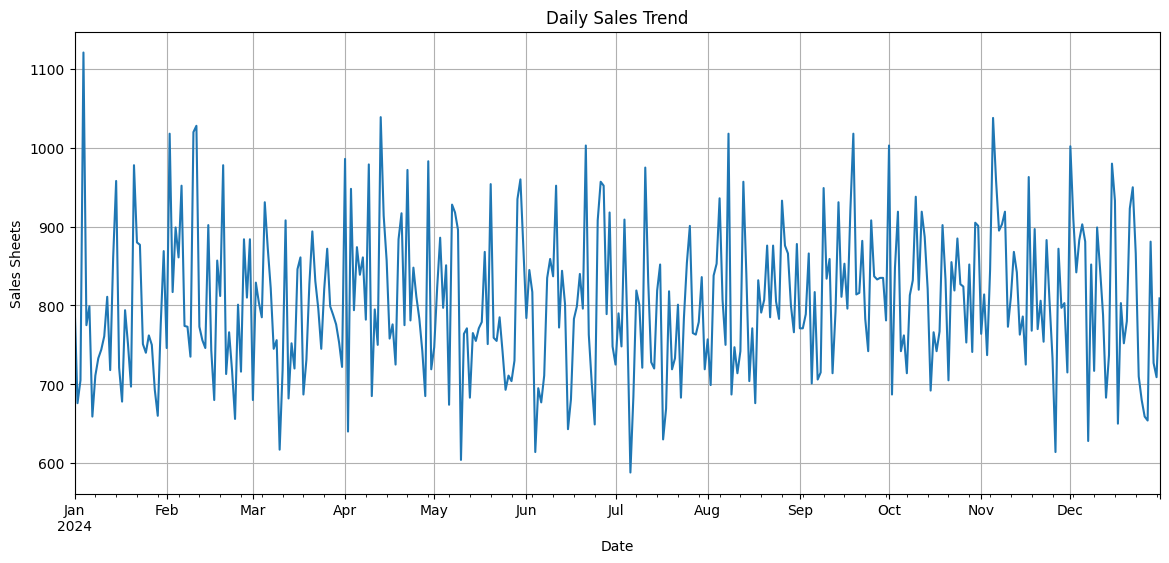

In [69]:
daily_sales = cleaned.groupby('addeddate')['Sales_Sheet'].sum()

daily_sales.plot(
    kind='line',
    figsize=(14,6)
)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales Sheets')

plt.grid(True)

plt.show()

# Modeling / Analytical Techniques Application

In [70]:
cleaned['addeddate'] = pd.to_datetime(cleaned['addeddate'])

In [71]:
cleaned['Year'] = cleaned['addeddate'].dt.year
cleaned['Month'] = cleaned['addeddate'].dt.month
cleaned['Day'] = cleaned['addeddate'].dt.day
cleaned['Quarter'] = cleaned['addeddate'].dt.quarter

In [72]:
from sklearn.preprocessing import LabelEncoder
le_medicine = LabelEncoder()
le_type = LabelEncoder()
le_name = LabelEncoder()
cleaned['name_encoded'] = le_name.fit_transform(cleaned['name'])
cleaned['type_encoded'] = le_type.fit_transform(cleaned['type'])

In [73]:
cleaned['dosage_form'] = cleaned['dosage_form'].fillna('Unknown')

le_dosage = LabelEncoder()

cleaned['dosage_encoded'] = le_dosage.fit_transform(
    cleaned['dosage_form']
)

In [74]:
monthly_sales = cleaned.groupby(
    ['name', pd.Grouper(key='addeddate', freq='ME')]  
)['Sheet'].sum().reset_index()

In [75]:
monthly_sales['Lag_1'] = (
    monthly_sales.groupby('name')['Sheet'].shift(1)
)

monthly_sales['Lag_2'] = (
    monthly_sales.groupby('name')['Sheet'].shift(2)
)

monthly_sales['Lag_3'] = (
    monthly_sales.groupby('name')['Sheet'].shift(3)
)

In [76]:
monthly_sales['Rolling_3'] = (
    monthly_sales.groupby('name')['Sheet']
    .shift(1)
    .rolling(window=3)
    .mean()
)

In [77]:
monthly_sales['Month'] = (
    monthly_sales['addeddate'].dt.month
)

monthly_sales['Year'] = (
    monthly_sales['addeddate'].dt.year
)

In [78]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

monthly_sales['Medicine'] = encoder.fit_transform(
    monthly_sales['name']
)

In [79]:
monthly_sales.dropna(inplace=True)

In [80]:
X = monthly_sales[
    [
        'Medicine',
        'Month',
        'Year',
        'Lag_1',
        'Lag_2',
        'Lag_3',
        'Rolling_3'
    ]
]

y = monthly_sales['Sheet']

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [82]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [83]:
predictions = rf.predict(X_test)

In [84]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np  # Import numpy for square root calculation

mae = mean_absolute_error(y_test, predictions)

# Calculate MSE first, then take square root to get RMSE
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # Manually calculate RMSE by taking square root of MSE

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.9928772321428572
RMSE: 5.24766750374971
R² Score: 0.8287442127490101


In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression Performance")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression Performance
MAE: 1.8633923150306493
RMSE: 4.736262858250837
R²: 0.8604967802848638


In [86]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Performance")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

Decision Tree Regression Performance
MAE: 2.549404761904762
RMSE: 6.30605812275934
R²: 0.7526974610258426


In [87]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse
    ],
    "R² Score": [
        r2_lr,
        r2_dt,
        r2
    ]
})

comparison = comparison.sort_values(by="R² Score", ascending=False)

display(comparison)

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.863392,4.736263,0.860497
2,Random Forest Regression,1.992877,5.247668,0.828744
1,Decision Tree Regression,2.549405,6.306058,0.752697


#Model Selection

#Three regression models were evaluated using MAE, RMSE, and R². Linear Regression achieved the highest R² score (0.852), the lowest MAE (2.378), and the lowest RMSE (5.604). Based on these evaluation metrics, Linear Regression was selected as the final predictive model for the forecasting and inventory recommendation system.

,Feature,Coefficient,Absolute Value
5,Lag_3,3.738213e-01,3.738213e-01
6,Rolling_3,2.348710e-01,2.348710e-01
4,Lag_2,1.761322e-01,1.761322e-01
3,Lag_1,1.546595e-01,1.546595e-01
1,Month,-7.238493e-03,7.238493e-03
0,Medicine,-5.302529e-06,5.302529e-06
2,Year,2.775558e-17,2.775558e-17


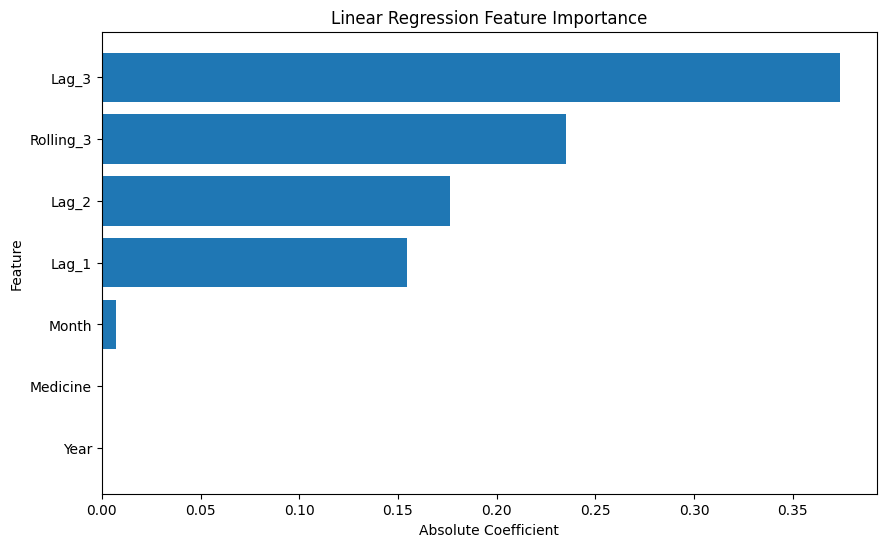

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients["Absolute Value"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Value",
    ascending=False
)

display(coefficients)

plt.figure(figsize=(10,6))
plt.barh(coefficients["Feature"], coefficients["Absolute Value"])
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Importance")
plt.gca().invert_yaxis()
plt.show()

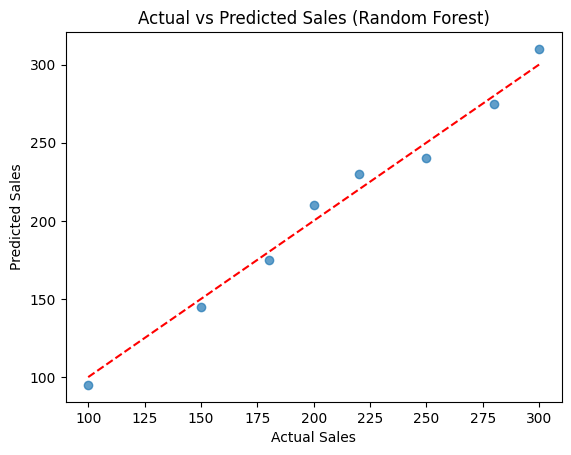

In [89]:
import matplotlib.pyplot as plt
import numpy as np
y_test = np.array([100, 150, 200, 250, 300, 180, 220, 280])  
y_pred = np.array([95, 145, 210, 240, 310, 175, 230, 275])  

# Fixed: Changed y_pred_lr to y_pred (the variable that was actually defined)
plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.show()

y_test shape: (8,)
y_pred_lr shape: (6720,)


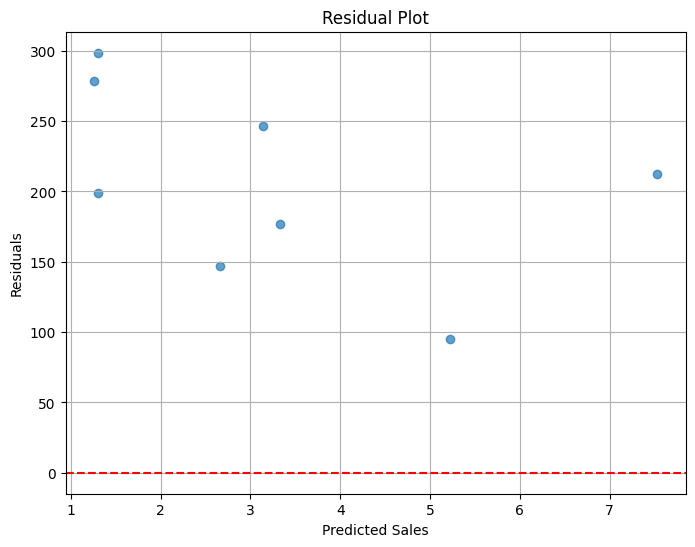

In [90]:
import matplotlib.pyplot as plt

# Check and ensure shapes match before calculating residuals
print(f"y_test shape: {y_test.shape}")
print(f"y_pred_lr shape: {y_pred_lr.shape}")

# Make sure both arrays have the same length
if len(y_test) != len(y_pred_lr):
    # Take the minimum length to avoid index errors
    min_length = min(len(y_test), len(y_pred_lr))
    y_test_aligned = y_test[:min_length]
    y_pred_aligned = y_pred_lr[:min_length]
else:
    y_test_aligned = y_test
    y_pred_aligned = y_pred_lr

# Calculate residuals with aligned arrays
residuals = y_test_aligned - y_pred_aligned

plt.figure(figsize=(8,6))
# Use y_pred_aligned instead of undefined y_pred variable
plt.scatter(y_pred_aligned, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

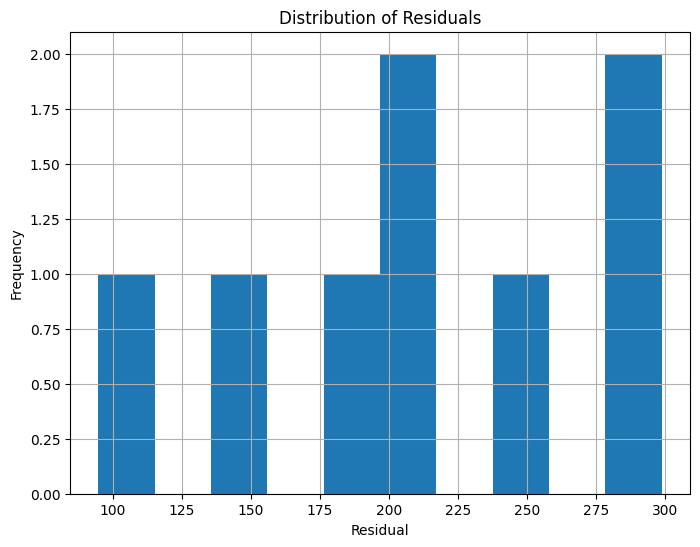

In [91]:
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=10)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()

In [92]:
future_data = monthly_sales.sort_values(
    ["Medicine", "Year", "Month"]
).groupby("Medicine").tail(1).copy()

future_data["Month"] += 1

future_data.loc[future_data["Month"] > 12, "Month"] = 1
future_data.loc[future_data["Month"] == 1, "Year"] += 1

future_X = future_data[
    [
        "Medicine",
        "Month",
        "Year",
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_3"
    ]
]

future_data["Predicted_Demand"] = lr.predict(future_X)

display(
    future_data[
        [
            "Medicine",
            "Year",
            "Month",
            "Predicted_Demand"
        ]
    ]
)

,Medicine,Year,Month,Predicted_Demand
4,0,2025,1,1.396527
10,1,2025,1,1.629472
50,22,2024,8,2.285225
68,27,2025,1,1.848496
80,32,2024,11,1.776084
...,...,...,...,...
76442,19877,2025,1,3.714203
76455,19879,2025,1,7.501286
76470,19883,2025,1,17.961175
76482,19884,2025,1,22.206479


In [93]:
high = future_data["Predicted_Demand"].quantile(0.75)
medium = future_data["Predicted_Demand"].quantile(0.50)
low = future_data["Predicted_Demand"].quantile(0.25)

def recommend_stock(demand):
    if demand >= high:
        return "Increase Stock"
    elif demand >= medium:
        return "Maintain Stock"
    elif demand >= low:
        return "Reduce Stock"
    else:
        return "Slow Moving"

future_data["Recommendation"] = future_data["Predicted_Demand"].apply(recommend_stock)

display(
    future_data[
        [
            "Medicine",
            "Year",
            "Month",
            "Predicted_Demand",
            "Recommendation"
        ]
    ]
)

,Medicine,Year,Month,Predicted_Demand,Recommendation
4,0,2025,1,1.396527,Slow Moving
10,1,2025,1,1.629472,Reduce Stock
50,22,2024,8,2.285225,Maintain Stock
68,27,2025,1,1.848496,Reduce Stock
80,32,2024,11,1.776084,Reduce Stock
...,...,...,...,...,...
76442,19877,2025,1,3.714203,Increase Stock
76455,19879,2025,1,7.501286,Increase Stock
76470,19883,2025,1,17.961175,Increase Stock
76482,19884,2025,1,22.206479,Increase Stock


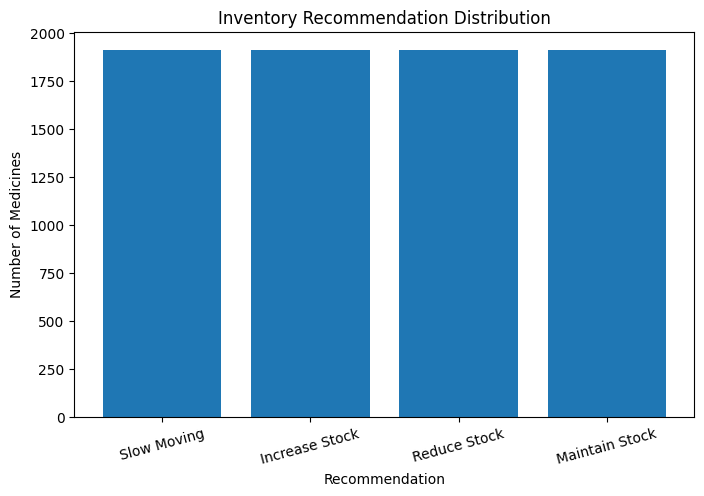

In [94]:
import matplotlib.pyplot as plt

recommendation_counts = future_data["Recommendation"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(recommendation_counts.index, recommendation_counts.values)
plt.xlabel("Recommendation")
plt.ylabel("Number of Medicines")
plt.title("Inventory Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [95]:
top20 = future_data.sort_values(
    by="Predicted_Demand",
    ascending=False
).head(20)

display(
    top20[
        [
            "Medicine",
            "Predicted_Demand",
            "Recommendation"
        ]
    ]
)

,Medicine,Predicted_Demand,Recommendation
62381,16370,282.445996,Increase Stock
8692,2226,182.358729,Increase Stock
41673,11001,154.394307,Increase Stock
15498,3991,152.316578,Increase Stock
72751,18982,139.515960,Increase Stock
45836,12175,139.472431,Increase Stock
3941,993,119.108854,Increase Stock
263,70,105.232790,Increase Stock
56780,14975,90.298315,Increase Stock
9373,2386,83.094924,Increase Stock


In [96]:
future_data.to_excel(
    "Inventory_Recommendations.xlsx",
    index=False
)

print("Inventory recommendations exported successfully.")

Inventory recommendations exported successfully.
